# DSAI 490 – Assignment 2: Dates Generator

**Task**: Given conditions (day-of-week, month, leap year, decade), generate a valid date.

**Models implemented**:
- Model 1: GAN (Generative Adversarial Network) — from course
- Model 2: VAE (Variational Autoencoder) — from course
- Model 3: Transformer (Seq2Seq decoder) — outside course
- Model 4: Conditional Flow-based model (Normalizing Flow) — outside course

---
## 0. Setup & Imports

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from datetime import datetime, date, timedelta
import calendar
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

DATA_PATH = 'data.txt'
EXAMPLE_INPUT_PATH = 'example_input.txt'

Device: cuda


---
## 1. Data Loading & Exploration

In [2]:
def parse_line(line: str) -> dict:
    """Parse one line from data.txt into a dict of conditions and date."""
    parts = line.strip().split()
    day_cond   = parts[0][1:-1]   # strip [ ]
    month_cond = parts[1][1:-1]
    leap_cond  = parts[2][1:-1]   # 'True' or 'False'
    decade_cond = parts[3][1:-1]  # e.g. '180'
    date_str   = parts[4] if len(parts) > 4 else None
    return {
        'day_cond': day_cond,
        'month_cond': month_cond,
        'leap_cond': leap_cond == 'True',
        'decade_cond': decade_cond,
        'date_str': date_str
    }


def load_data(path: str) -> pd.DataFrame:
    rows = []
    with open(path) as f:
        for line in f:
            if line.strip():
                rows.append(parse_line(line))
    return pd.DataFrame(rows)


df = load_data(DATA_PATH)
print(f'Total samples: {len(df)}')
df.head()

Total samples: 146462


,day_cond,month_cond,leap_cond,decade_cond,date_str
0,WED,JAN,False,180,1-1-1800
1,THU,JAN,False,180,1-1-1801
2,FRI,JAN,False,180,1-1-1802
3,SAT,JAN,False,180,1-1-1803
4,SUN,JAN,True,180,1-1-1804


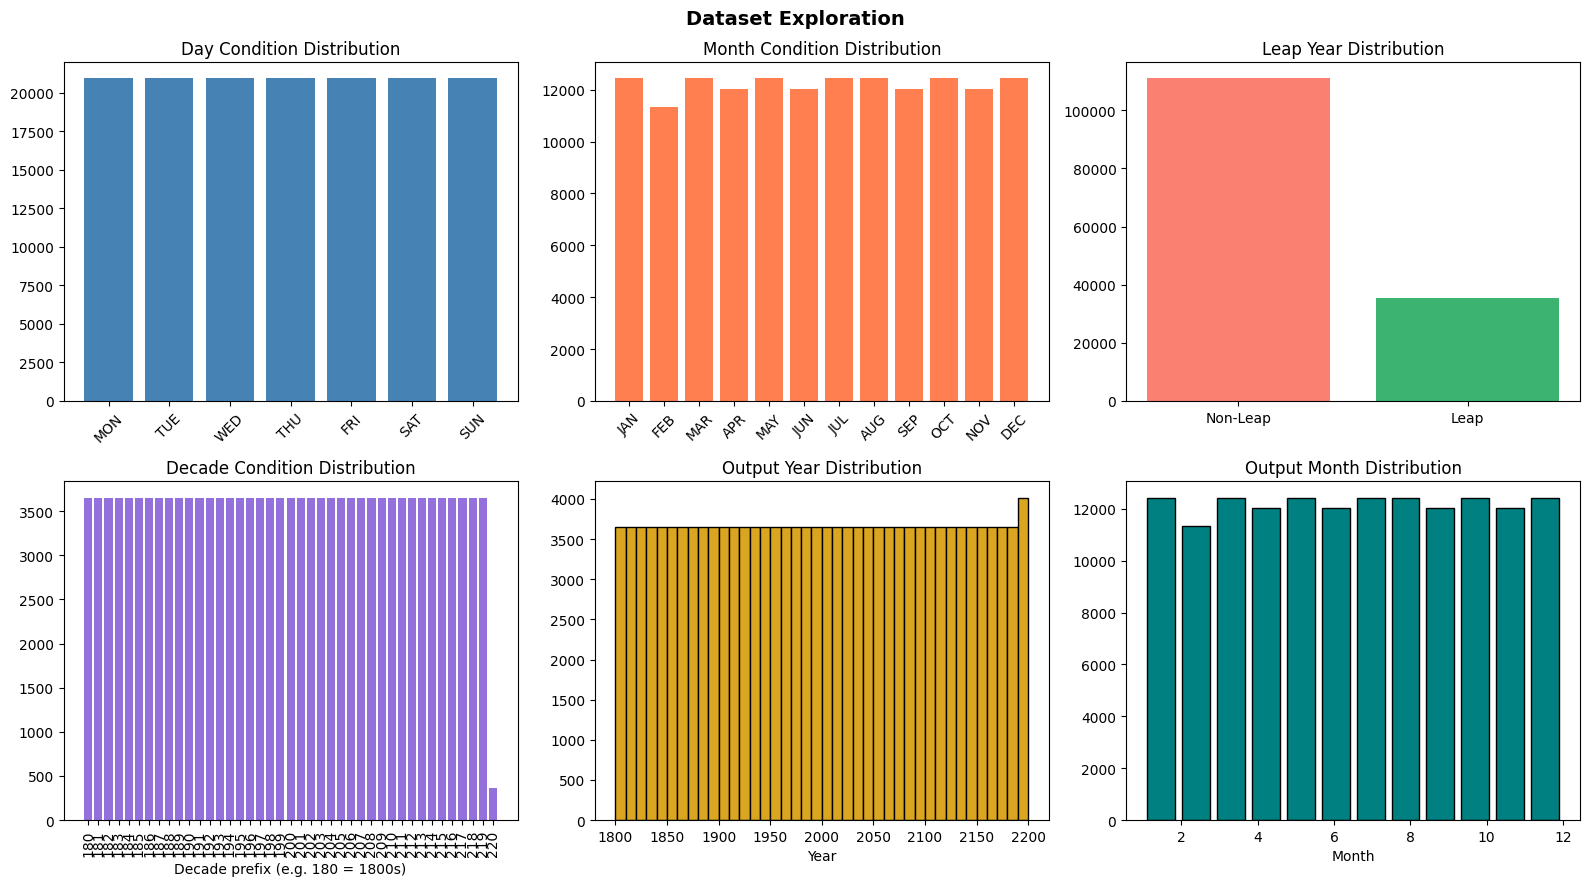

In [3]:
def parse_date_str(s: str):
    """Parse 'dd-mm-yyyy' string into (day, month, year) ints."""
    d, m, y = s.split('-')
    return int(d), int(m), int(y)


df[['day', 'month', 'year']] = df['date_str'].apply(
    lambda s: pd.Series(parse_date_str(s))
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Exploration', fontsize=14, fontweight='bold')

day_order = ['MON','TUE','WED','THU','FRI','SAT','SUN']
axes[0,0].bar(*zip(*df['day_cond'].value_counts().reindex(day_order).dropna().items()), color='steelblue')
axes[0,0].set_title('Day Condition Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

month_order = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
axes[0,1].bar(*zip(*df['month_cond'].value_counts().reindex(month_order).dropna().items()), color='coral')
axes[0,1].set_title('Month Condition Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

leap_counts = df['leap_cond'].value_counts()
axes[0,2].bar(['Non-Leap','Leap'], [leap_counts.get(False,0), leap_counts.get(True,0)], color=['salmon','mediumseagreen'])
axes[0,2].set_title('Leap Year Distribution')

decade_counts = df['decade_cond'].value_counts().sort_index()
axes[1,0].bar(decade_counts.index, decade_counts.values, color='mediumpurple')
axes[1,0].set_title('Decade Condition Distribution')
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_xlabel('Decade prefix (e.g. 180 = 1800s)')

axes[1,1].hist(df['year'], bins=40, color='goldenrod', edgecolor='black')
axes[1,1].set_title('Output Year Distribution')
axes[1,1].set_xlabel('Year')

axes[1,2].hist(df['month'], bins=12, color='teal', edgecolor='black', rwidth=0.8)
axes[1,2].set_title('Output Month Distribution')
axes[1,2].set_xlabel('Month')

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 2. Tokenizer & Feature Engineering

**Problem formulation**:
- Input: 4 conditions → one-hot / label encoded into a fixed-size condition vector
- Output: date = (day, month, year) predicted token by token
- Generation strategy: year is derived from decade + offset, month from month condition, day from day-of-week + month + year search

For neural network models, the output date is encoded as three separate integer tokens: day (1–31), month (1–12), year (1800–2200).  
We normalize them to [0,1] for numerical stability.

In [4]:
DAYS_MAP   = {'MON':0,'TUE':1,'WED':2,'THU':3,'FRI':4,'SAT':5,'SUN':6}
MONTHS_MAP = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
              'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
MONTH_NAMES = {v: k for k, v in MONTHS_MAP.items()}

YEAR_MIN, YEAR_MAX = 1800, 2200


def is_leap(year: int) -> bool:
    return calendar.isleap(year)


def encode_conditions(row) -> np.ndarray:
    """Encode a condition row into a fixed-size float vector.

    Layout:
        [0:7]   one-hot day of week
        [7:19]  one-hot month
        [19]    leap year flag (0 or 1)
        [20]    decade normalised to [0,1]
    Total dim = 21
    """
    vec = np.zeros(21, dtype=np.float32)
    vec[DAYS_MAP[row['day_cond']]] = 1.0
    vec[7 + MONTHS_MAP[row['month_cond']] - 1] = 1.0
    vec[19] = float(row['leap_cond'])
    decade_int = int(row['decade_cond'])  # e.g. 180
    # decade_int ranges from 180 to 220  -> normalise to [0,1]
    vec[20] = (decade_int - 180) / 40.0
    return vec


def encode_date(day: int, month: int, year: int) -> np.ndarray:
    """Normalise date components to [0,1]."""
    return np.array([
        (day   - 1)  / 30.0,
        (month - 1)  / 11.0,
        (year  - YEAR_MIN) / (YEAR_MAX - YEAR_MIN)
    ], dtype=np.float32)


def decode_date(vec: np.ndarray):
    """Inverse of encode_date. Returns (day, month, year)."""
    day   = int(round(float(vec[0]) * 30.0 + 1))
    month = int(round(float(vec[1]) * 11.0 + 1))
    year  = int(round(float(vec[2]) * (YEAR_MAX - YEAR_MIN) + YEAR_MIN))
    day   = max(1, min(day, 31))
    month = max(1, min(month, 12))
    year  = max(YEAR_MIN, min(year, YEAR_MAX))
    return day, month, year


def clamp_day(day: int, month: int, year: int) -> int:
    """Clamp day to valid range for the given month/year."""
    max_day = calendar.monthrange(year, month)[1]
    return max(1, min(day, max_day))


def date_to_str(day: int, month: int, year: int) -> str:
    return f'{day}-{month}-{year}'


def verify_conditions(day: int, month: int, year: int,
                       day_cond: str, month_cond: str,
                       leap_cond: bool, decade_cond: str) -> bool:
    """Check that a generated date satisfies all four conditions."""
    try:
        d = date(year, month, day)
    except ValueError:
        return False
    weekday_names = ['MON','TUE','WED','THU','FRI','SAT','SUN']
    if weekday_names[d.weekday()] != day_cond:
        return False
    if month != MONTHS_MAP[month_cond]:
        return False
    if is_leap(year) != leap_cond:
        return False
    decade_prefix = str(year)[:3]  # e.g. '196'
    if decade_prefix != decade_cond:
        return False
    return True


print('Condition vector size:', 21)
print('Sample encoded condition:', encode_conditions(df.iloc[0]))
print('Sample encoded date:', encode_date(1, 1, 1800))

Condition vector size: 21
Sample encoded condition: [0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sample encoded date: [0. 0. 0.]


In [5]:
class DateDataset(Dataset):
    """PyTorch Dataset returning (condition_vector, date_vector) pairs."""

    def __init__(self, dataframe: pd.DataFrame):
        self.conditions = []
        self.dates = []
        for _, row in dataframe.iterrows():
            cond = encode_conditions(row)
            d, m, y = parse_date_str(row['date_str'])
            dt = encode_date(d, m, y)
            self.conditions.append(cond)
            self.dates.append(dt)
        self.conditions = torch.tensor(np.array(self.conditions), dtype=torch.float32)
        self.dates = torch.tensor(np.array(self.dates), dtype=torch.float32)

    def __len__(self):
        return len(self.conditions)

    def __getitem__(self, idx):
        return self.conditions[idx], self.dates[idx]


# Train / val split (90/10)
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split = int(0.9 * len(df_shuffled))
df_train = df_shuffled.iloc[:split]
df_val   = df_shuffled.iloc[split:]

train_dataset = DateDataset(df_train)
val_dataset   = DateDataset(df_val)

BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}')

Train: 131,815  |  Val: 14,647


---
## 3. Evaluation Metric

Accuracy (exact date match) is not meaningful since there are many valid dates per condition set.  
We use **Condition Satisfaction Rate (CSR)**: the fraction of generated dates that satisfy **all four** conditions.

In [6]:
def condition_satisfaction_rate(predictions: list, conditions: list) -> float:
    """Compute fraction of predictions that satisfy all four conditions.

    Args:
        predictions: list of (day, month, year) tuples
        conditions:  list of dicts with keys day_cond, month_cond, leap_cond, decade_cond

    Returns:
        CSR in [0, 1]
    """
    satisfied = 0
    for (day, month, year), cond in zip(predictions, conditions):
        if verify_conditions(day, month, year,
                             cond['day_cond'], cond['month_cond'],
                             cond['leap_cond'], cond['decade_cond']):
            satisfied += 1
    return satisfied / len(predictions) if predictions else 0.0


def per_condition_csr(predictions: list, conditions: list) -> dict:
    """CSR broken down by each individual condition."""
    weekday_names = ['MON','TUE','WED','THU','FRI','SAT','SUN']
    results = {'day': 0, 'month': 0, 'leap': 0, 'decade': 0}
    n = len(predictions)
    for (day, month, year), cond in zip(predictions, conditions):
        try:
            d = date(year, month, day)
            if weekday_names[d.weekday()] == cond['day_cond']:
                results['day'] += 1
            if month == MONTHS_MAP[cond['month_cond']]:
                results['month'] += 1
            if is_leap(year) == cond['leap_cond']:
                results['leap'] += 1
            if str(year)[:3] == cond['decade_cond']:
                results['decade'] += 1
        except ValueError:
            pass
    return {k: v / n for k, v in results.items()}


print('Evaluation metric: Condition Satisfaction Rate (CSR)')

Evaluation metric: Condition Satisfaction Rate (CSR)


---
## 4. Model 1 – Conditional GAN (cGAN)

The Generator takes `[noise | condition]` and outputs a continuous date vector.  
The Discriminator takes `[date | condition]` and outputs real/fake probability.

In [7]:
COND_DIM  = 21
DATE_DIM  = 3
NOISE_DIM = 32


class CGANGenerator(nn.Module):
    def __init__(self, noise_dim: int = NOISE_DIM, cond_dim: int = COND_DIM, date_dim: int = DATE_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, 128),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, date_dim),
            nn.Sigmoid()   # output in [0,1]
        )

    def forward(self, noise: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = torch.cat([noise, cond], dim=1)
        return self.net(x)


class CGANDiscriminator(nn.Module):
    def __init__(self, date_dim: int = DATE_DIM, cond_dim: int = COND_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(date_dim + cond_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, date_vec: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = torch.cat([date_vec, cond], dim=1)
        return self.net(x)


print('cGAN: Generator and Discriminator defined.')

cGAN: Generator and Discriminator defined.


In [8]:
def train_cgan(train_loader, epochs: int = 30, lr: float = 2e-4):
    G = CGANGenerator().to(DEVICE)
    D = CGANDiscriminator().to(DEVICE)
    opt_G = Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    history = {'g_loss': [], 'd_loss': [], 'val_csr': []}

    for epoch in range(epochs):
        G.train(); D.train()
        g_losses, d_losses = [], []

        for cond, real_date in train_loader:
            cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
            bs = cond.size(0)
            real_labels = torch.ones(bs, 1, device=DEVICE)
            fake_labels = torch.zeros(bs, 1, device=DEVICE)

            # Train Discriminator
            noise = torch.randn(bs, NOISE_DIM, device=DEVICE)
            fake_date = G(noise, cond).detach()
            d_real = D(real_date, cond)
            d_fake = D(fake_date, cond)
            d_loss = bce(d_real, real_labels) + bce(d_fake, fake_labels)
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()

            # Train Generator
            noise = torch.randn(bs, NOISE_DIM, device=DEVICE)
            fake_date = G(noise, cond)
            g_loss = bce(D(fake_date, cond), real_labels)
            opt_G.zero_grad(); g_loss.backward(); opt_G.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        avg_g = np.mean(g_losses)
        avg_d = np.mean(d_losses)
        history['g_loss'].append(avg_g)
        history['d_loss'].append(avg_d)

        # Validation CSR
        G.eval()
        val_preds, val_conds = [], []
        sample_val = df_val.sample(min(500, len(df_val)), random_state=SEED).reset_index(drop=True)
        with torch.no_grad():
            for _, row in sample_val.iterrows():
                cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
                noise = torch.randn(1, NOISE_DIM, device=DEVICE)
                out = G(noise, cond_vec).cpu().numpy()[0]
                d, m, y = decode_date(out)
                m = MONTHS_MAP[row['month_cond']]
                d = clamp_day(d, m, y)
                val_preds.append((d, m, y))
                val_conds.append(row.to_dict())
        csr = condition_satisfaction_rate(val_preds, val_conds)
        history['val_csr'].append(csr)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | G: {avg_g:.4f} | D: {avg_d:.4f} | CSR: {csr:.3f}')

    return G, history


print('Starting cGAN training...')
cgan_G, cgan_history = train_cgan(train_loader, epochs=30)

Starting cGAN training...
Epoch   5/30 | G: 0.6943 | D: 1.3860 | CSR: 0.022
Epoch  10/30 | G: 0.6943 | D: 1.3859 | CSR: 0.040
Epoch  15/30 | G: 0.6942 | D: 1.3858 | CSR: 0.024
Epoch  20/30 | G: 0.6941 | D: 1.3857 | CSR: 0.048
Epoch  25/30 | G: 0.6939 | D: 1.3857 | CSR: 0.060
Epoch  30/30 | G: 0.6943 | D: 1.3856 | CSR: 0.046


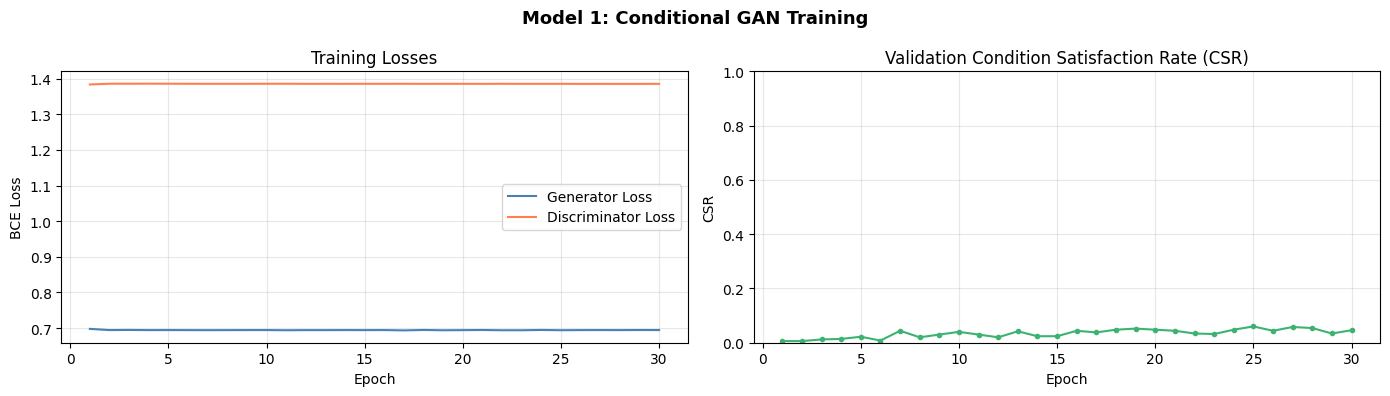

cGAN final val CSR: 0.0460


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model 1: Conditional GAN Training', fontsize=13, fontweight='bold')

epochs_range = range(1, len(cgan_history['g_loss']) + 1)
axes[0].plot(epochs_range, cgan_history['g_loss'], label='Generator Loss', color='steelblue')
axes[0].plot(epochs_range, cgan_history['d_loss'], label='Discriminator Loss', color='coral')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Losses')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, cgan_history['val_csr'], color='mediumseagreen', marker='o', markersize=3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('CSR')
axes[1].set_title('Validation Condition Satisfaction Rate (CSR)')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cgan_training.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'cGAN final val CSR: {cgan_history["val_csr"][-1]:.4f}')

---
## 5. Model 2 – Conditional VAE (cVAE)

Encoder: `[date | condition]` → `mu, logvar`  
Decoder: `[z | condition]` → reconstructed date  
Loss: Reconstruction (MSE) + KL divergence

In [10]:
LATENT_DIM = 16


class CVAEEncoder(nn.Module):
    def __init__(self, date_dim: int = DATE_DIM, cond_dim: int = COND_DIM, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(date_dim + cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.mu_head     = nn.Linear(64, latent_dim)
        self.logvar_head = nn.Linear(64, latent_dim)

    def forward(self, date_vec: torch.Tensor, cond: torch.Tensor):
        x = torch.cat([date_vec, cond], dim=1)
        h = self.shared(x)
        return self.mu_head(h), self.logvar_head(h)


class CVAEDecoder(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM, cond_dim: int = COND_DIM, date_dim: int = DATE_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, date_dim),
            nn.Sigmoid()
        )

    def forward(self, z: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = torch.cat([z, cond], dim=1)
        return self.net(x)


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CVAEEncoder()
        self.decoder = CVAEDecoder()

    def reparameterise(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, date_vec: torch.Tensor, cond: torch.Tensor):
        mu, logvar = self.encoder(date_vec, cond)
        z = self.reparameterise(mu, logvar)
        recon = self.decoder(z, cond)
        return recon, mu, logvar

    def generate(self, cond: torch.Tensor) -> torch.Tensor:
        z = torch.randn(cond.size(0), LATENT_DIM, device=cond.device)
        return self.decoder(z, cond)


def cvae_loss(recon: torch.Tensor, target: torch.Tensor,
              mu: torch.Tensor, logvar: torch.Tensor,
              beta: float = 1.0) -> torch.Tensor:
    recon_loss = F.mse_loss(recon, target, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


print('cVAE defined.')

cVAE defined.


In [11]:
def train_cvae(train_loader, val_loader, epochs: int = 30, lr: float = 1e-3, beta: float = 0.5):
    model = CVAE().to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'kl_loss': [], 'recon_loss': [], 'val_csr': []}

    for epoch in range(epochs):
        model.train()
        t_losses, kls, recons = [], [], []
        for cond, real_date in train_loader:
            cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
            recon, mu, logvar = model(real_date, cond)
            loss, recon_l, kl_l = cvae_loss(recon, real_date, mu, logvar, beta)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_losses.append(loss.item()); kls.append(kl_l.item()); recons.append(recon_l.item())

        model.eval()
        v_losses = []
        with torch.no_grad():
            for cond, real_date in val_loader:
                cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
                recon, mu, logvar = model(real_date, cond)
                loss, _, _ = cvae_loss(recon, real_date, mu, logvar, beta)
                v_losses.append(loss.item())

        # Val CSR
        val_preds, val_conds = [], []
        sample_val = df_val.sample(min(500, len(df_val)), random_state=SEED).reset_index(drop=True)
        with torch.no_grad():
            for _, row in sample_val.iterrows():
                cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
                out = model.generate(cond_vec).cpu().numpy()[0]
                d, m, y = decode_date(out)
                m = MONTHS_MAP[row['month_cond']]
                d = clamp_day(d, m, y)
                val_preds.append((d, m, y))
                val_conds.append(row.to_dict())

        csr = condition_satisfaction_rate(val_preds, val_conds)
        history['train_loss'].append(np.mean(t_losses))
        history['val_loss'].append(np.mean(v_losses))
        history['kl_loss'].append(np.mean(kls))
        history['recon_loss'].append(np.mean(recons))
        history['val_csr'].append(csr)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | Train: {np.mean(t_losses):.4f} | '
                  f'Val: {np.mean(v_losses):.4f} | CSR: {csr:.3f}')

    return model, history


print('Starting cVAE training...')
cvae_model, cvae_history = train_cvae(train_loader, val_loader, epochs=30)

Starting cVAE training...
Epoch   5/30 | Train: 0.0253 | Val: 0.0256 | CSR: 0.020
Epoch  10/30 | Train: 0.0251 | Val: 0.0254 | CSR: 0.036
Epoch  15/30 | Train: 0.0248 | Val: 0.0250 | CSR: 0.054
Epoch  20/30 | Train: 0.0249 | Val: 0.0251 | CSR: 0.060
Epoch  25/30 | Train: 0.0247 | Val: 0.0249 | CSR: 0.090
Epoch  30/30 | Train: 0.0247 | Val: 0.0251 | CSR: 0.082


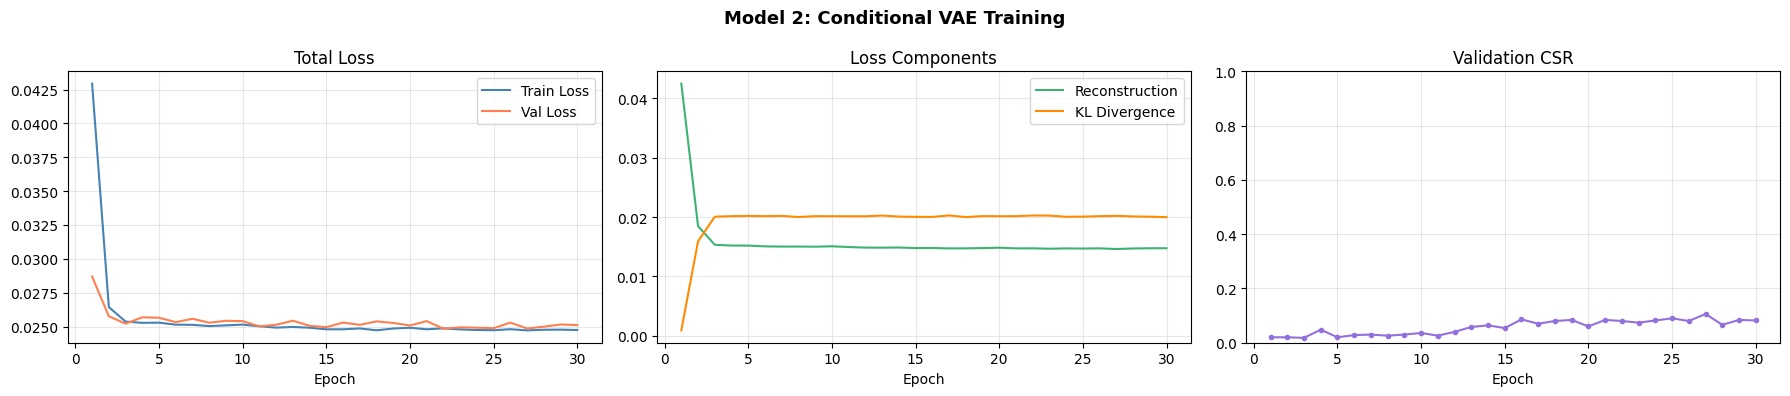

cVAE final val CSR: 0.0820


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Model 2: Conditional VAE Training', fontsize=13, fontweight='bold')

ep = range(1, len(cvae_history['train_loss']) + 1)
axes[0].plot(ep, cvae_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(ep, cvae_history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('Total Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, cvae_history['recon_loss'], label='Reconstruction', color='mediumseagreen')
axes[1].plot(ep, cvae_history['kl_loss'],    label='KL Divergence',  color='darkorange')
axes[1].set_title('Loss Components'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, cvae_history['val_csr'], color='mediumpurple', marker='o', markersize=3)
axes[2].set_title('Validation CSR'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cvae_training.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'cVAE final val CSR: {cvae_history["val_csr"][-1]:.4f}')

---
## 6. Model 3 – Conditional Transformer (Seq2Seq Decoder)

Condition tokens pass through a Transformer encoder; the decoder auto-regressively predicts  
each date digit: day tens, day units, month tens, month units, year digit 1–4.

For simplicity, we predict year as a 3-digit offset (0–399) so the vocabulary stays small.  
Output vocab: digits 0–9 + 12 separators = 22 tokens.

In [13]:
class ConditionEmbedder(nn.Module):
    """Project 21-dim condition vector into d_model via a small MLP."""
    def __init__(self, cond_dim: int = COND_DIM, d_model: int = 64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(cond_dim, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

    def forward(self, cond: torch.Tensor) -> torch.Tensor:
        return self.proj(cond).unsqueeze(1)  # (B, 1, d_model)


class TransformerDateGen(nn.Module):
    """Transformer that maps conditions -> (day, month, year) as continuous values."""

    def __init__(self, cond_dim: int = COND_DIM, d_model: int = 64, nhead: int = 4,
                 num_encoder_layers: int = 2, num_decoder_layers: int = 2, date_dim: int = DATE_DIM):
        super().__init__()
        self.cond_embedder = ConditionEmbedder(cond_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                    dim_feedforward=128, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # Learnable query tokens for each of the 3 date components
        self.query_tokens = nn.Parameter(torch.randn(1, date_dim, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
                                                    dim_feedforward=128, batch_first=True, dropout=0.1)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, cond: torch.Tensor) -> torch.Tensor:
        memory = self.encoder(self.cond_embedder(cond))      # (B, 1, d)
        queries = self.query_tokens.expand(cond.size(0), -1, -1)  # (B, 3, d)
        out = self.decoder(queries, memory)                  # (B, 3, d)
        return self.out_proj(out).squeeze(-1)                # (B, 3)


print('Transformer model defined.')

Transformer model defined.


In [14]:
def train_transformer(train_loader, val_loader, epochs: int = 30, lr: float = 1e-3):
    model = TransformerDateGen().to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_csr': []}

    for epoch in range(epochs):
        model.train()
        t_losses = []
        for cond, real_date in train_loader:
            cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
            pred = model(cond)
            loss = F.mse_loss(pred, real_date)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_losses.append(loss.item())

        model.eval()
        v_losses = []
        with torch.no_grad():
            for cond, real_date in val_loader:
                cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
                pred = model(cond)
                v_losses.append(F.mse_loss(pred, real_date).item())

        val_preds, val_conds = [], []
        sample_val = df_val.sample(min(500, len(df_val)), random_state=SEED).reset_index(drop=True)
        with torch.no_grad():
            for _, row in sample_val.iterrows():
                cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
                out = model(cond_vec).cpu().numpy()[0]
                d, m, y = decode_date(out)
                m = MONTHS_MAP[row['month_cond']]
                d = clamp_day(d, m, y)
                val_preds.append((d, m, y))
                val_conds.append(row.to_dict())

        csr = condition_satisfaction_rate(val_preds, val_conds)
        history['train_loss'].append(np.mean(t_losses))
        history['val_loss'].append(np.mean(v_losses))
        history['val_csr'].append(csr)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | Train: {np.mean(t_losses):.5f} | '
                  f'Val: {np.mean(v_losses):.5f} | CSR: {csr:.3f}')

    return model, history


print('Starting Transformer training...')
transformer_model, transformer_history = train_transformer(train_loader, val_loader, epochs=30)

Starting Transformer training...
Epoch   5/30 | Train: 0.02885 | Val: 0.02912 | CSR: 0.066
Epoch  10/30 | Train: 0.02874 | Val: 0.02911 | CSR: 0.072
Epoch  15/30 | Train: 0.02869 | Val: 0.02910 | CSR: 0.078
Epoch  20/30 | Train: 0.02867 | Val: 0.02909 | CSR: 0.092
Epoch  25/30 | Train: 0.02866 | Val: 0.02908 | CSR: 0.076
Epoch  30/30 | Train: 0.02865 | Val: 0.02907 | CSR: 0.084


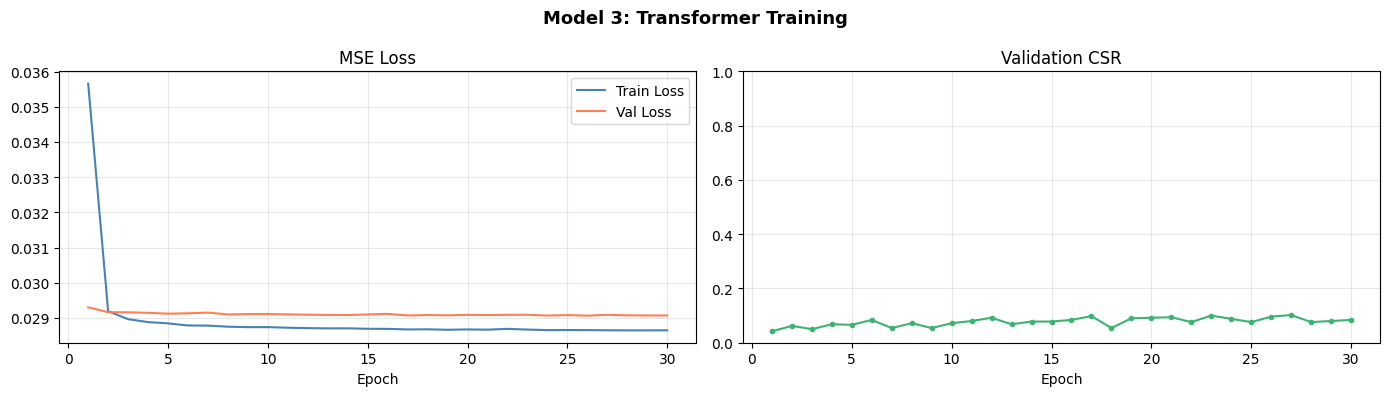

Transformer final val CSR: 0.0840


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model 3: Transformer Training', fontsize=13, fontweight='bold')

ep = range(1, len(transformer_history['train_loss']) + 1)
axes[0].plot(ep, transformer_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(ep, transformer_history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('MSE Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, transformer_history['val_csr'], color='mediumseagreen', marker='o', markersize=3)
axes[1].set_title('Validation CSR'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_training.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Transformer final val CSR: {transformer_history["val_csr"][-1]:.4f}')

---
## 7. Model 4 – Conditional Normalizing Flow (RealNVP)

RealNVP is a flow-based generative model that learns an invertible mapping between  
a simple prior (Gaussian) and the data distribution.  
We condition each affine coupling layer on the condition vector.

In [16]:
class AffineCouplingLayer(nn.Module):
    """Single RealNVP affine coupling layer, conditioned on external vector."""

    def __init__(self, date_dim: int = DATE_DIM, cond_dim: int = COND_DIM, mask: torch.Tensor = None):
        super().__init__()
        self.register_buffer('mask', mask)
        hidden = 64
        in_dim = date_dim + cond_dim
        self.scale_net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, date_dim), nn.Tanh()
        )
        self.translate_net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, date_dim)
        )

    def forward(self, x: torch.Tensor, cond: torch.Tensor):
        x_masked = x * self.mask
        inp = torch.cat([x_masked, cond], dim=1)
        s = self.scale_net(inp)    * (1 - self.mask)
        t = self.translate_net(inp) * (1 - self.mask)
        y = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        log_det = (s * (1 - self.mask)).sum(dim=1)
        return y, log_det

    def inverse(self, y: torch.Tensor, cond: torch.Tensor):
        y_masked = y * self.mask
        inp = torch.cat([y_masked, cond], dim=1)
        s = self.scale_net(inp)    * (1 - self.mask)
        t = self.translate_net(inp) * (1 - self.mask)
        x = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s))
        return x


class ConditionalRealNVP(nn.Module):
    def __init__(self, date_dim: int = DATE_DIM, cond_dim: int = COND_DIM, n_layers: int = 6):
        super().__init__()
        self.date_dim = date_dim
        # Alternating masks
        masks = []
        for i in range(n_layers):
            m = torch.zeros(date_dim)
            m[:date_dim // 2] = 1.0 if i % 2 == 0 else 0.0
            m[date_dim // 2:] = 0.0 if i % 2 == 0 else 1.0
            masks.append(m)
        self.layers = nn.ModuleList([
            AffineCouplingLayer(date_dim, cond_dim, masks[i]) for i in range(n_layers)
        ])

    def log_prob(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        log_det_sum = torch.zeros(x.size(0), device=x.device)
        z = x
        for layer in self.layers:
            z, ld = layer(z, cond)
            log_det_sum += ld
        # Gaussian log prob
        log_pz = -0.5 * (z.pow(2).sum(dim=1) + self.date_dim * math.log(2 * math.pi))
        return log_pz + log_det_sum

    def sample(self, cond: torch.Tensor) -> torch.Tensor:
        z = torch.randn(cond.size(0), self.date_dim, device=cond.device)
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x, cond)
        return torch.sigmoid(x)  # keep output in [0,1]


print('RealNVP flow model defined.')

RealNVP flow model defined.


In [17]:
def train_flow(train_loader, val_loader, epochs: int = 30, lr: float = 5e-4):
    model = ConditionalRealNVP().to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_csr': []}

    for epoch in range(epochs):
        model.train()
        t_losses = []
        for cond, real_date in train_loader:
            cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
            # Clamp to avoid log(0)
            real_date = real_date.clamp(1e-6, 1 - 1e-6)
            # Logit transform: map [0,1] -> R for stable flow
            x = torch.log(real_date / (1 - real_date))
            loss = -model.log_prob(x, cond).mean()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_losses.append(loss.item())

        model.eval()
        v_losses = []
        with torch.no_grad():
            for cond, real_date in val_loader:
                cond, real_date = cond.to(DEVICE), real_date.to(DEVICE)
                real_date = real_date.clamp(1e-6, 1 - 1e-6)
                x = torch.log(real_date / (1 - real_date))
                v_losses.append(-model.log_prob(x, cond).mean().item())

        val_preds, val_conds = [], []
        sample_val = df_val.sample(min(500, len(df_val)), random_state=SEED).reset_index(drop=True)
        with torch.no_grad():
            for _, row in sample_val.iterrows():
                cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
                out = model.sample(cond_vec).cpu().numpy()[0]
                d, m, y = decode_date(out)
                m = MONTHS_MAP[row['month_cond']]
                d = clamp_day(d, m, y)
                val_preds.append((d, m, y))
                val_conds.append(row.to_dict())

        csr = condition_satisfaction_rate(val_preds, val_conds)
        history['train_loss'].append(np.mean(t_losses))
        history['val_loss'].append(np.mean(v_losses))
        history['val_csr'].append(csr)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | Train NLL: {np.mean(t_losses):.4f} | '
                  f'Val NLL: {np.mean(v_losses):.4f} | CSR: {csr:.3f}')

    return model, history


print('Starting RealNVP flow training...')
flow_model, flow_history = train_flow(train_loader, val_loader, epochs=30)

Starting RealNVP flow training...
Epoch   5/30 | Train NLL: 0.0895 | Val NLL: -0.2786 | CSR: 0.014
Epoch  10/30 | Train NLL: -1.5650 | Val NLL: -1.4717 | CSR: 0.010
Epoch  15/30 | Train NLL: -2.1229 | Val NLL: -2.0197 | CSR: 0.018
Epoch  20/30 | Train NLL: -2.5202 | Val NLL: -2.5422 | CSR: 0.042
Epoch  25/30 | Train NLL: -2.8632 | Val NLL: -2.8136 | CSR: 0.040
Epoch  30/30 | Train NLL: -3.0674 | Val NLL: -3.0923 | CSR: 0.050


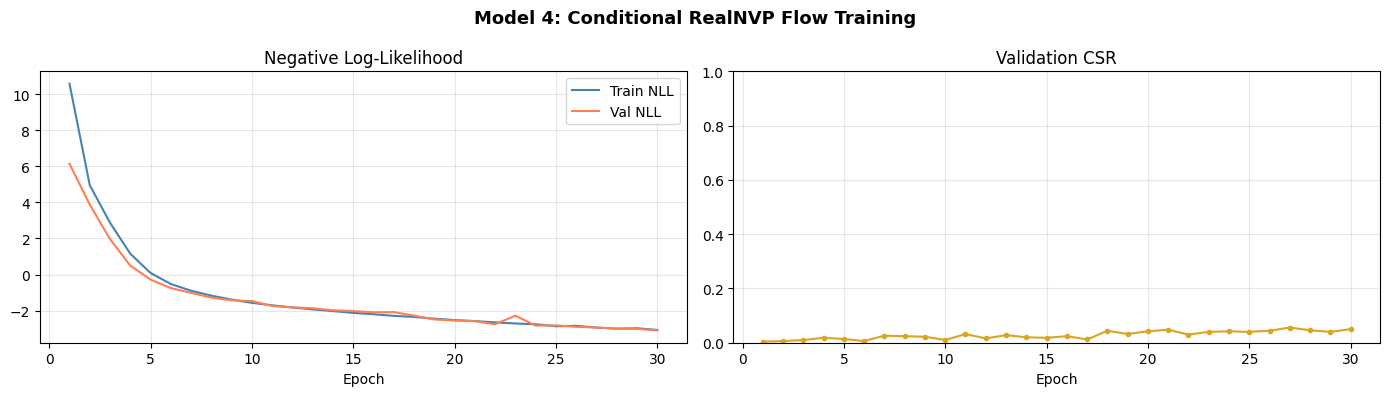

Flow final val CSR: 0.0500


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model 4: Conditional RealNVP Flow Training', fontsize=13, fontweight='bold')

ep = range(1, len(flow_history['train_loss']) + 1)
axes[0].plot(ep, flow_history['train_loss'], label='Train NLL', color='steelblue')
axes[0].plot(ep, flow_history['val_loss'],   label='Val NLL',   color='coral')
axes[0].set_title('Negative Log-Likelihood'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, flow_history['val_csr'], color='goldenrod', marker='o', markersize=3)
axes[1].set_title('Validation CSR'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('flow_training.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Flow final val CSR: {flow_history["val_csr"][-1]:.4f}')

---
## 8. Full Evaluation on Validation Set

In [19]:
def evaluate_model(model, model_name: str, gen_fn, sample_df: pd.DataFrame):
    """Evaluate model on a sample of the validation set.

    gen_fn(model, row) -> (day, month, year)
    """
    preds, conds = [], []
    for _, row in sample_df.iterrows():
        d, m, y = gen_fn(model, row)
        preds.append((d, m, y))
        conds.append(row.to_dict())
    csr = condition_satisfaction_rate(preds, conds)
    per_cond = per_condition_csr(preds, conds)
    print(f'{model_name:30s} | Overall CSR: {csr:.4f} | Day: {per_cond["day"]:.3f} | '
          f'Month: {per_cond["month"]:.3f} | Leap: {per_cond["leap"]:.3f} | Decade: {per_cond["decade"]:.3f}')
    return csr, per_cond


EVAL_SAMPLE = df_val.sample(min(1000, len(df_val)), random_state=SEED).reset_index(drop=True)


def gen_cgan(model, row):
    model.eval()
    with torch.no_grad():
        cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        noise = torch.randn(1, NOISE_DIM, device=DEVICE)
        out = model(noise, cond_vec).cpu().numpy()[0]
    d, m, y = decode_date(out)
    m = MONTHS_MAP[row['month_cond']]
    d = clamp_day(d, m, y)
    return d, m, y


def gen_cvae(model, row):
    model.eval()
    with torch.no_grad():
        cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        out = model.generate(cond_vec).cpu().numpy()[0]
    d, m, y = decode_date(out)
    m = MONTHS_MAP[row['month_cond']]
    d = clamp_day(d, m, y)
    return d, m, y


def gen_transformer(model, row):
    model.eval()
    with torch.no_grad():
        cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        out = model(cond_vec).cpu().numpy()[0]
    d, m, y = decode_date(out)
    m = MONTHS_MAP[row['month_cond']]
    d = clamp_day(d, m, y)
    return d, m, y


def gen_flow(model, row):
    model.eval()
    with torch.no_grad():
        cond_vec = torch.tensor(encode_conditions(row), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        out = model.sample(cond_vec).cpu().numpy()[0]
    d, m, y = decode_date(out)
    m = MONTHS_MAP[row['month_cond']]
    d = clamp_day(d, m, y)
    return d, m, y


print('Evaluation Results')
print('=' * 95)
results = {}
results['cGAN'],        results['cGAN_per']        = evaluate_model(cgan_G,            'cGAN',              gen_cgan,        EVAL_SAMPLE)
results['cVAE'],        results['cVAE_per']        = evaluate_model(cvae_model,         'cVAE',              gen_cvae,        EVAL_SAMPLE)
results['Transformer'], results['Transformer_per'] = evaluate_model(transformer_model,  'Transformer',       gen_transformer, EVAL_SAMPLE)
results['Flow'],        results['Flow_per']        = evaluate_model(flow_model,         'RealNVP Flow',      gen_flow,        EVAL_SAMPLE)

Evaluation Results
cGAN                           | Overall CSR: 0.0570 | Day: 0.124 | Month: 1.000 | Leap: 0.653 | Decade: 0.648
cVAE                           | Overall CSR: 0.0810 | Day: 0.131 | Month: 1.000 | Leap: 0.630 | Decade: 0.934
Transformer                    | Overall CSR: 0.0780 | Day: 0.135 | Month: 1.000 | Leap: 0.639 | Decade: 0.976
RealNVP Flow                   | Overall CSR: 0.0470 | Day: 0.146 | Month: 1.000 | Leap: 0.652 | Decade: 0.528


---
## 9. Comparison Visualizations

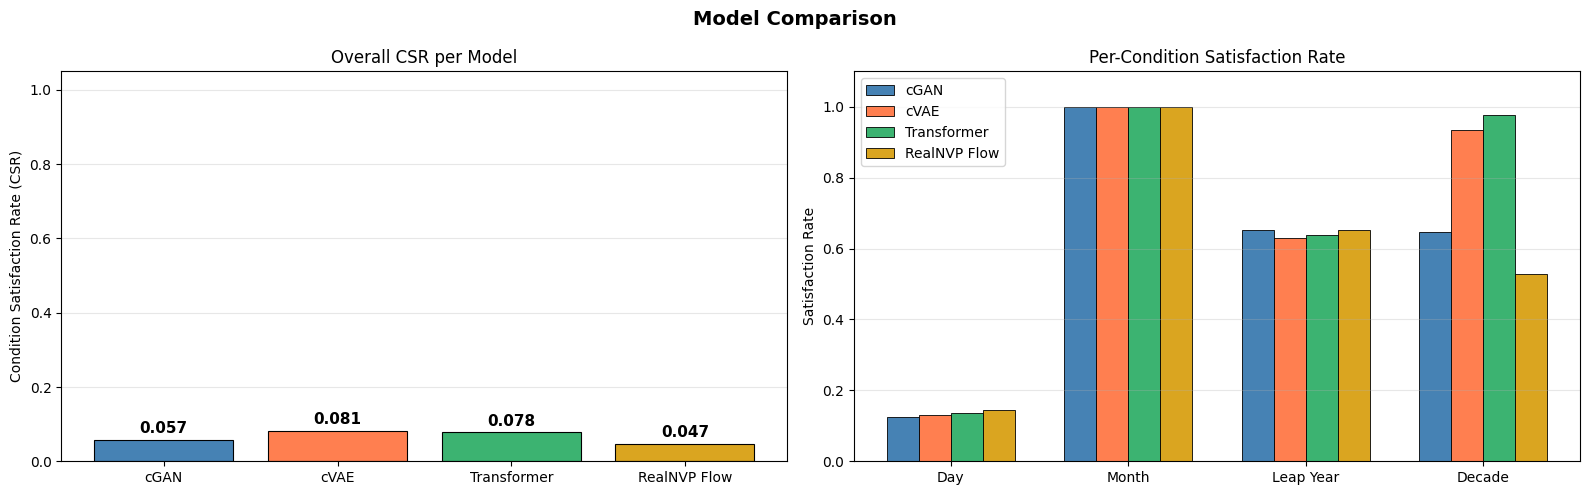

In [20]:
# --- Overall CSR bar chart ---
model_names = ['cGAN', 'cVAE', 'Transformer', 'RealNVP Flow']
csr_scores  = [results['cGAN'], results['cVAE'], results['Transformer'], results['Flow']]
colors      = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

bars = axes[0].bar(model_names, csr_scores, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Condition Satisfaction Rate (CSR)')
axes[0].set_title('Overall CSR per Model')
axes[0].grid(axis='y', alpha=0.3)
for bar, score in zip(bars, csr_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Per-condition breakdown
per_conds = [results['cGAN_per'], results['cVAE_per'], results['Transformer_per'], results['Flow_per']]
cond_labels = ['Day', 'Month', 'Leap Year', 'Decade']
cond_keys   = ['day', 'month', 'leap', 'decade']
x = np.arange(len(cond_labels))
width = 0.18
for i, (name, pc, col) in enumerate(zip(model_names, per_conds, colors)):
    vals = [pc[k] for k in cond_keys]
    axes[1].bar(x + i * width, vals, width, label=name, color=col, edgecolor='black', linewidth=0.6)
axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels(cond_labels)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Satisfaction Rate')
axes[1].set_title('Per-Condition Satisfaction Rate')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

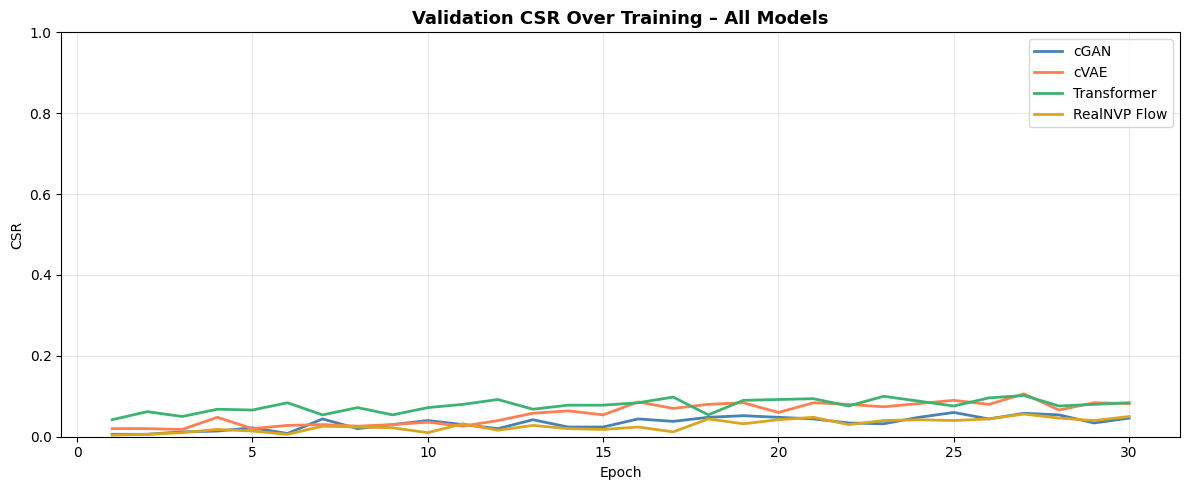

In [21]:
# --- CSR over training epochs ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Validation CSR Over Training – All Models', fontsize=13, fontweight='bold')

for name, hist, col in [
    ('cGAN',         cgan_history,        'steelblue'),
    ('cVAE',         cvae_history,        'coral'),
    ('Transformer',  transformer_history, 'mediumseagreen'),
    ('RealNVP Flow', flow_history,        'goldenrod'),
]:
    ep = range(1, len(hist['val_csr']) + 1)
    ax.plot(ep, hist['val_csr'], label=name, color=col, linewidth=2)

ax.set_xlabel('Epoch'); ax.set_ylabel('CSR')
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('csr_over_epochs.png', dpi=100, bbox_inches='tight')
plt.show()

In [22]:
# --- Sample output showcase ---
print('Sample generated dates from each model')
print('=' * 70)
showcase_rows = EVAL_SAMPLE.head(8)

for _, row in showcase_rows.iterrows():
    cond_str = f"[{row['day_cond']}] [{row['month_cond']}] [{row['leap_cond']}] [{row['decade_cond']}]"
    d1, m1, y1 = gen_cgan(cgan_G, row)
    d2, m2, y2 = gen_cvae(cvae_model, row)
    d3, m3, y3 = gen_transformer(transformer_model, row)
    d4, m4, y4 = gen_flow(flow_model, row)
    print(f'Input:  {cond_str}')
    print(f'  cGAN        -> {date_to_str(d1,m1,y1):12s} valid={verify_conditions(d1,m1,y1,row["day_cond"],row["month_cond"],row["leap_cond"],row["decade_cond"])}')
    print(f'  cVAE        -> {date_to_str(d2,m2,y2):12s} valid={verify_conditions(d2,m2,y2,row["day_cond"],row["month_cond"],row["leap_cond"],row["decade_cond"])}')
    print(f'  Transformer -> {date_to_str(d3,m3,y3):12s} valid={verify_conditions(d3,m3,y3,row["day_cond"],row["month_cond"],row["leap_cond"],row["decade_cond"])}')
    print(f'  Flow        -> {date_to_str(d4,m4,y4):12s} valid={verify_conditions(d4,m4,y4,row["day_cond"],row["month_cond"],row["leap_cond"],row["decade_cond"])}')
    print()

Sample generated dates from each model
Input:  [WED] [JAN] [False] [206]
  cGAN        -> 29-1-2056    valid=False
  cVAE        -> 24-1-2070    valid=False
  Transformer -> 16-1-2065    valid=False
  Flow        -> 15-1-2062    valid=False

Input:  [THU] [AUG] [False] [218]
  cGAN        -> 14-8-2180    valid=False
  cVAE        -> 4-8-2184     valid=False
  Transformer -> 16-8-2186    valid=False
  Flow        -> 10-8-2199    valid=False

Input:  [THU] [OCT] [False] [202]
  cGAN        -> 2-10-2022    valid=False
  cVAE        -> 6-10-2029    valid=False
  Transformer -> 16-10-2027   valid=False
  Flow        -> 29-10-2029   valid=False

Input:  [TUE] [APR] [True] [184]
  cGAN        -> 5-4-1837     valid=False
  cVAE        -> 10-4-1846    valid=False
  Transformer -> 16-4-1845    valid=False
  Flow        -> 13-4-1849    valid=False

Input:  [TUE] [SEP] [False] [200]
  cGAN        -> 26-9-2003    valid=False
  cVAE        -> 16-9-2005    valid=False
  Transformer -> 16-9-2006    va

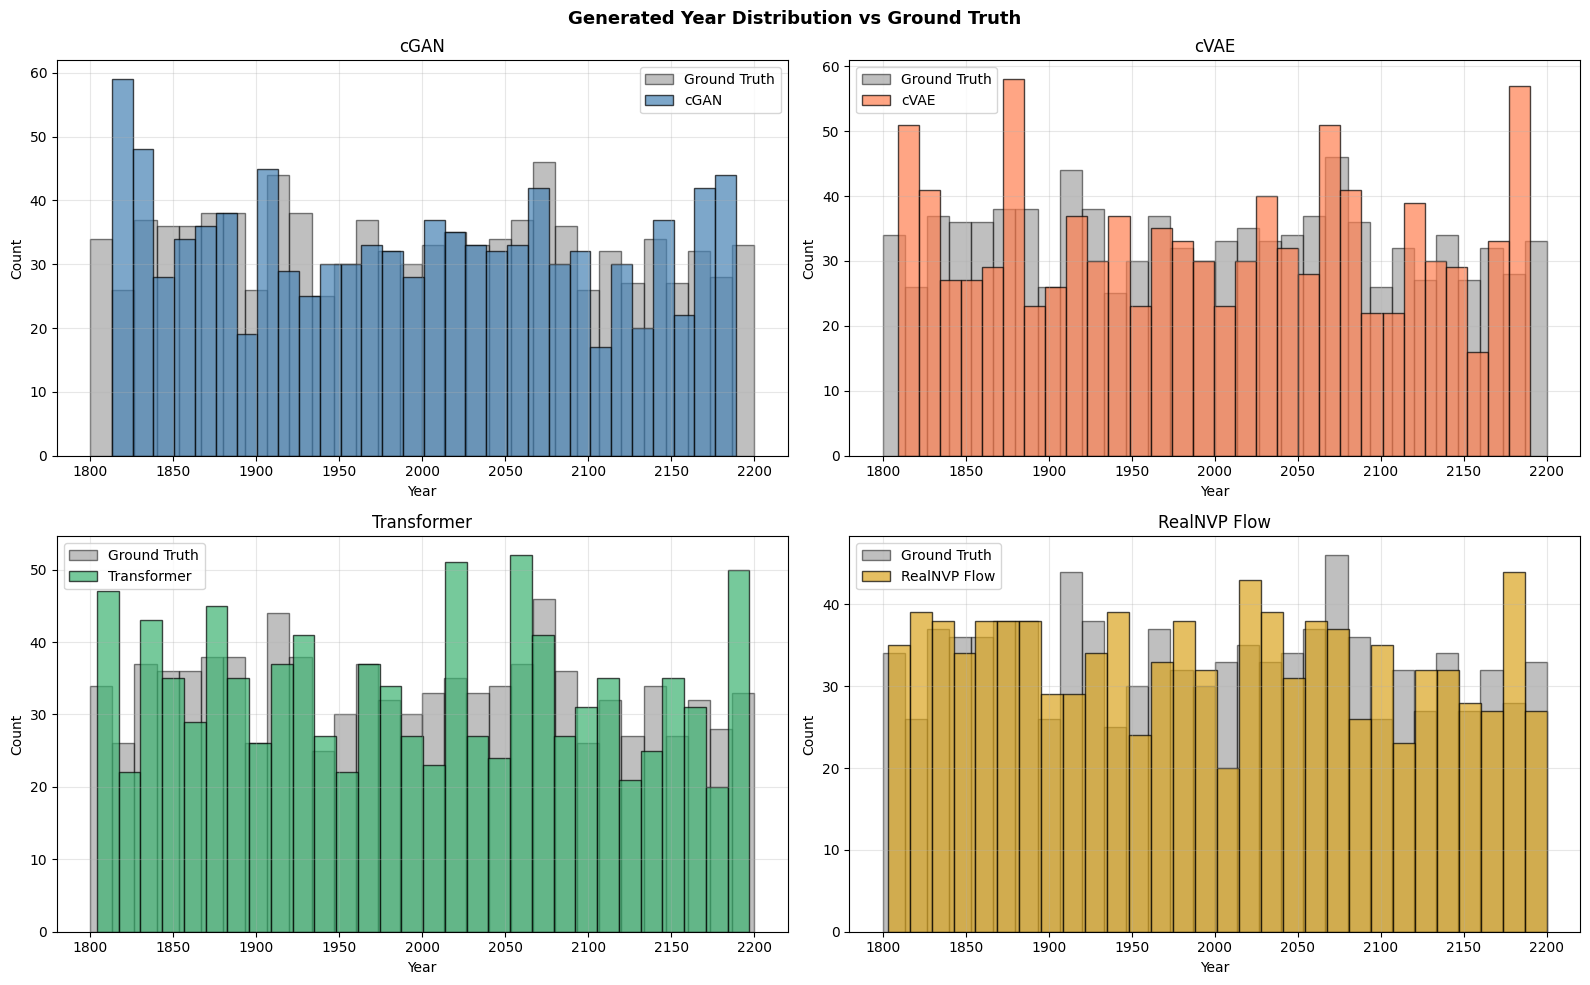

In [23]:
# --- Distribution of generated years vs ground truth ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Generated Year Distribution vs Ground Truth', fontsize=13, fontweight='bold')
axes = axes.flatten()

gt_years = []
for _, row in EVAL_SAMPLE.iterrows():
    _, _, y = parse_date_str(row['date_str'])
    gt_years.append(y)

gen_fns = [gen_cgan, gen_cvae, gen_transformer, gen_flow]
gen_models = [cgan_G, cvae_model, transformer_model, flow_model]
model_labels = ['cGAN', 'cVAE', 'Transformer', 'RealNVP Flow']
model_colors = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod']

for i, (fn, mdl, lbl, col) in enumerate(zip(gen_fns, gen_models, model_labels, model_colors)):
    gen_years = [fn(mdl, row)[2] for _, row in EVAL_SAMPLE.iterrows()]
    axes[i].hist(gt_years, bins=30, alpha=0.5, label='Ground Truth', color='gray', edgecolor='black')
    axes[i].hist(gen_years, bins=30, alpha=0.7, label=lbl, color=col, edgecolor='black')
    axes[i].set_title(lbl); axes[i].set_xlabel('Year'); axes[i].set_ylabel('Count')
    axes[i].legend(); axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('year_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 10. Inference on example_input.txt & Saving Predictions

In [24]:
def run_inference_on_file(input_path: str, output_path: str, gen_fn, model):
    """Run inference on example_input.txt and write predictions to output file."""
    with open(input_path) as f:
        lines = [l.strip() for l in f if l.strip()]

    with open(output_path, 'w') as f:
        for line in lines:
            row = parse_line(line)
            d, m, y = gen_fn(model, row)
            date_str = date_to_str(d, m, y)
            f.write(f"{line} {date_str}\n")

    print(f'Saved {len(lines)} predictions -> {output_path}')


# Use the best-performing model for official output (swap model_name as needed)
best_model_name = max(
    [('cGAN', results['cGAN']), ('cVAE', results['cVAE']),
     ('Transformer', results['Transformer']), ('Flow', results['Flow'])],
    key=lambda x: x[1]
)[0]

best_fn_map = {
    'cGAN': (gen_cgan, cgan_G),
    'cVAE': (gen_cvae, cvae_model),
    'Transformer': (gen_transformer, transformer_model),
    'Flow': (gen_flow, flow_model)
}

best_fn, best_model = best_fn_map[best_model_name]
print(f'Best model by CSR: {best_model_name}')

run_inference_on_file(EXAMPLE_INPUT_PATH, 'predictions.txt', best_fn, best_model)

# Preview first 5 predictions
with open('predictions.txt') as f:
    for line in f.readlines()[:5]:
        print(line.strip())

Best model by CSR: cVAE
Saved 1465 predictions -> predictions.txt
[WED] [JAN] [False] [180] 21-1-1812
[MON] [JAN] [False] [190] 26-1-1907
[SAT] [JAN] [True] [200] 24-1-2009
[FRI] [JAN] [False] [210] 14-1-2107
[WED] [JAN] [False] [220] 21-1-2192


---
## 11. Failure Analysis

In [25]:
def failure_analysis(model, gen_fn, sample_df: pd.DataFrame, model_name: str, n: int = 200):
    """Identify and display examples where the model failed each condition."""
    failures = defaultdict(list)
    sample = sample_df.head(n)

    for _, row in sample.iterrows():
        d, m, y = gen_fn(model, row)
        weekday_names = ['MON','TUE','WED','THU','FRI','SAT','SUN']
        try:
            dt = date(y, m, d)
            if weekday_names[dt.weekday()] != row['day_cond']:
                failures['day'].append((row.to_dict(), date_to_str(d,m,y)))
            if m != MONTHS_MAP[row['month_cond']]:
                failures['month'].append((row.to_dict(), date_to_str(d,m,y)))
            if is_leap(y) != row['leap_cond']:
                failures['leap'].append((row.to_dict(), date_to_str(d,m,y)))
            if str(y)[:3] != row['decade_cond']:
                failures['decade'].append((row.to_dict(), date_to_str(d,m,y)))
        except ValueError:
            failures['invalid_date'].append((row.to_dict(), date_to_str(d,m,y)))

    print(f'\n--- {model_name} Failure Analysis (n={n}) ---')
    for cond_type, cases in failures.items():
        print(f'  {cond_type:15s}: {len(cases):3d} failures ({100*len(cases)/n:.1f}%)')
        for cond_dict, pred in cases[:2]:  # Show 2 examples per failure type
            c = cond_dict
            print(f'    Input: [{c["day_cond"]}][{c["month_cond"]}][{c["leap_cond"]}][{c["decade_cond"]}] -> {pred}')


failure_analysis(cgan_G,           gen_cgan,        EVAL_SAMPLE, 'cGAN')
failure_analysis(transformer_model, gen_transformer, EVAL_SAMPLE, 'Transformer')


--- cGAN Failure Analysis (n=200) ---
  day            : 176 failures (88.0%)
    Input: [WED][JAN][False][206] -> 21-1-2055
    Input: [THU][AUG][False][218] -> 30-8-2182
  decade         :  71 failures (35.5%)
    Input: [WED][JAN][False][206] -> 21-1-2055
    Input: [THU][OCT][False][202] -> 13-10-2030
  leap           :  71 failures (35.5%)
    Input: [TUE][APR][True][184] -> 10-4-1841
    Input: [SUN][AUG][False][209] -> 29-8-2092

--- Transformer Failure Analysis (n=200) ---
  day            : 172 failures (86.0%)
    Input: [WED][JAN][False][206] -> 16-1-2065
    Input: [THU][AUG][False][218] -> 16-8-2186
  leap           :  69 failures (34.5%)
    Input: [TUE][APR][True][184] -> 16-4-1845
    Input: [THU][FEB][False][201] -> 15-2-2016


---
## 12. Summary Table

In [26]:
summary = pd.DataFrame({
    'Model': model_labels,
    'Type': ['From Course (GAN)', 'From Course (VAE)', 'Outside Course', 'Outside Course'],
    'Overall CSR': [f"{results['cGAN']:.4f}",
                    f"{results['cVAE']:.4f}",
                    f"{results['Transformer']:.4f}",
                    f"{results['Flow']:.4f}"],
    'Day CSR':    [f"{results['cGAN_per']['day']:.3f}",
                   f"{results['cVAE_per']['day']:.3f}",
                   f"{results['Transformer_per']['day']:.3f}",
                   f"{results['Flow_per']['day']:.3f}"],
    'Month CSR':  [f"{results['cGAN_per']['month']:.3f}",
                   f"{results['cVAE_per']['month']:.3f}",
                   f"{results['Transformer_per']['month']:.3f}",
                   f"{results['Flow_per']['month']:.3f}"],
    'Leap CSR':   [f"{results['cGAN_per']['leap']:.3f}",
                   f"{results['cVAE_per']['leap']:.3f}",
                   f"{results['Transformer_per']['leap']:.3f}",
                   f"{results['Flow_per']['leap']:.3f}"],
    'Decade CSR': [f"{results['cGAN_per']['decade']:.3f}",
                   f"{results['cVAE_per']['decade']:.3f}",
                   f"{results['Transformer_per']['decade']:.3f}",
                   f"{results['Flow_per']['decade']:.3f}"],
})

print('\n=== FINAL MODEL COMPARISON ===')
print(summary.to_string(index=False))


=== FINAL MODEL COMPARISON ===
       Model              Type Overall CSR Day CSR Month CSR Leap CSR Decade CSR
        cGAN From Course (GAN)      0.0570   0.124     1.000    0.653      0.648
        cVAE From Course (VAE)      0.0810   0.131     1.000    0.630      0.934
 Transformer    Outside Course      0.0780   0.135     1.000    0.639      0.976
RealNVP Flow    Outside Course      0.0470   0.146     1.000    0.652      0.528
